# Import & Helper

In [1]:

# ============================================================
# Required definitions BEFORE the manual exact-M patch cell
# ============================================================
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
from dataclasses import dataclass
from typing import List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make sure uploaded modules are importable
sys.path.insert(0, "/mnt/data")

import noninteracting
import interaction
import frg_kernel
import frg_flow
import channels
import instability

from importlib import reload
reload(noninteracting)
reload(interaction)
reload(frg_kernel)
reload(frg_flow)
reload(channels)
reload(instability)

from noninteracting import KagomeNagaosa, KagomeStaggerFlux, KagomeKaneMeleSOC
from interaction import BareExtendedHubbard
from frg_flow import BareSZ0VertexFromInteraction, FRGFlowSolverSZ0
from channels import SZ0ChannelBuilder
from instability import InstabilityConfig, diagnose_kernel_collection

# ------------------------------------------------------------
# Lightweight patch containers (not relying on patching.py)
# ------------------------------------------------------------
@dataclass
class PatchPoint:
    patch_id: int
    k_cart: np.ndarray
    k_red: np.ndarray
    energy: float
    vF: np.ndarray
    vF_norm: float
    eigvec: np.ndarray
    orbital_weight: np.ndarray

@dataclass
class PatchSet:
    mu: float
    mu_used_for_contour: float
    band_index: int
    filling: float
    patches: List[PatchPoint]
    fs_contour_k: np.ndarray
    bz_vertices: np.ndarray
    b1: np.ndarray
    b2: np.ndarray
    gauge_method: str
    gauge_loop_phase: float

    @property
    def Npatch(self):
        return len(self.patches)

def plot_patchset(patchset, ax=None, title=None, show_ids=True, color='C0'):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    bz = np.asarray(patchset.bz_vertices, dtype=float)
    bz_closed = np.vstack([bz, bz[0]])
    ax.plot(bz_closed[:,0], bz_closed[:,1], 'k-', lw=1.0, alpha=0.7, label='1BZ')
    fs = np.asarray(patchset.fs_contour_k, dtype=float)
    if fs.size:
        fs_closed = np.vstack([fs, fs[0]])
        ax.plot(fs_closed[:,0], fs_closed[:,1], '-', color='0.6', lw=1.0, alpha=0.8, label='manual contour')
    ks = np.asarray([p.k_cart for p in patchset.patches], dtype=float)
    ax.scatter(ks[:,0], ks[:,1], s=50, color=color, zorder=3, label='patch reps')
    if show_ids:
        for p in patchset.patches:
            ax.text(p.k_cart[0], p.k_cart[1], str(p.patch_id), fontsize=8, ha='left', va='bottom')
    ax.set_aspect('equal')
    ax.set_xlabel(r'$k_x$')
    ax.set_ylabel(r'$k_y$')
    ax.set_title(title or f'Patch set (N={patchset.Npatch})')
    ax.legend(loc='best', fontsize=8)
    return ax

# ------------------------------------------------------------
# basic helpers
# ------------------------------------------------------------
def _sector_eig(model, k_cart, orbital_slice, band_index):
    kx, ky = float(k_cart[0]), float(k_cart[1])
    H = np.asarray(model.Hk(kx, ky), dtype=complex)
    Hs = H[orbital_slice, orbital_slice]
    evals, evecs = np.linalg.eigh(Hs)
    u = np.asarray(evecs[:, band_index], dtype=complex)
    u = u / np.linalg.norm(u)
    return float(evals[band_index]), u

def _orbital_weight(u):
    w = np.abs(np.asarray(u, dtype=complex))**2
    return w / np.sum(w)

def _cart_to_red(model, k):
    B = np.column_stack([
        np.asarray(model.b1, dtype=float),
        np.asarray(model.b2, dtype=float),
    ])
    return np.linalg.solve(B, np.asarray(k, dtype=float))

def _finite_diff_velocity(model, k_cart, orbital_slice, band_index, h=1e-6):
    kx, ky = float(k_cart[0]), float(k_cart[1])

    def band_energy(x, y):
        H = np.asarray(model.Hk(x, y), dtype=complex)
        Hs = H[orbital_slice, orbital_slice]
        evals, _ = np.linalg.eigh(Hs)
        return float(evals[band_index])

    vx = (band_energy(kx + h, ky) - band_energy(kx - h, ky)) / (2*h)
    vy = (band_energy(kx, ky + h) - band_energy(kx, ky - h)) / (2*h)
    return np.array([vx, vy], dtype=float)

# ------------------------------------------------------------
# reciprocal helpers
# ------------------------------------------------------------
def _wrap_unit_interval(x, tol=1e-12):
    x = np.asarray(x, dtype=float)
    x = x - np.floor(x)
    x[np.isclose(x, 1.0, atol=tol)] = 0.0
    x[np.isclose(x, 0.0, atol=tol)] = 0.0
    return x

def _canonicalize_k_mod_G(model, k):
    B = np.column_stack([
        np.asarray(model.b1, dtype=float),
        np.asarray(model.b2, dtype=float),
    ])
    uv = np.linalg.solve(B, np.asarray(k, dtype=float))
    uv = _wrap_unit_interval(uv)
    k_can = B @ uv
    k_can[np.isclose(k_can, 0.0, atol=1e-12)] = 0.0
    return k_can

# ------------------------------------------------------------
# 1BZ geometry
# ------------------------------------------------------------
def hex_bz_vertices(model):
    b1 = np.asarray(model.b1, dtype=float)
    b2 = np.asarray(model.b2, dtype=float)
    verts = np.array([
        (2*b1 - b2) / 3.0,
        (b1 + b2) / 3.0,
        (-b1 + 2*b2) / 3.0,
        -(2*b1 - b2) / 3.0,
        -(b1 + b2) / 3.0,
        -(-b1 + 2*b2) / 3.0,
    ], dtype=float)
    ang = np.arctan2(verts[:, 1], verts[:, 0])
    order = np.argsort(ang)
    return verts[order]

def exact_M6_points_1bz(model):
    V = hex_bz_vertices(model)
    M = []
    n = len(V)
    for i in range(n):
        v0 = V[i]
        v1 = V[(i + 1) % n]
        M.append(0.5 * (v0 + v1))
    M = np.asarray(M, dtype=float)
    ang = np.arctan2(M[:, 1], M[:, 0])
    order = np.argsort(ang)
    return M[order]

def exact_M_hex_loop_points(model, points_per_edge=1):
    if points_per_edge < 1:
        raise ValueError("points_per_edge must be >= 1")
    M6 = exact_M6_points_1bz(model)
    pts = []
    n = len(M6)
    for i in range(n):
        k0 = M6[i]
        k1 = M6[(i + 1) % n]
        for m in range(points_per_edge):
            t = m / points_per_edge
            pts.append((1.0 - t) * k0 + t * k1)
    return np.asarray(pts, dtype=float)

def _patch_keep_indices_remove_duplicate_M_anchors(model, points_per_edge, tol=1e-10):
    p = int(points_per_edge)
    n_full = 6 * p
    keep = np.ones(n_full, dtype=bool)
    anchor_ids = [i * p for i in range(6)]
    M6 = exact_M6_points_1bz(model)

    seen_classes = []
    for local_anchor_idx, global_idx in enumerate(anchor_ids):
        k_can = _canonicalize_k_mod_G(model, M6[local_anchor_idx])
        duplicated = any(np.linalg.norm(k_can - q_can) < tol for q_can in seen_classes)
        if duplicated:
            keep[global_idx] = False
        else:
            seen_classes.append(k_can)
    return np.flatnonzero(keep)

# ------------------------------------------------------------
# gauge fixing
# ------------------------------------------------------------
def _normalize_eigvec(u):
    u = np.asarray(u, dtype=complex)
    nrm = np.linalg.norm(u)
    if nrm == 0:
        raise ValueError("Encountered zero-norm eigenvector.")
    return u / nrm

def _anchor_phase(u, method="max_component"):
    u = _normalize_eigvec(u)
    if method == "max_component":
        idx = int(np.argmax(np.abs(u)))
    elif method == "first_component":
        nz = np.flatnonzero(np.abs(u) > 1e-14)
        idx = int(nz[0]) if len(nz) else 0
    else:
        raise ValueError("anchor_method must be 'max_component' or 'first_component'")
    phase = np.angle(u[idx]) if np.abs(u[idx]) > 0 else 0.0
    return u * np.exp(-1j * phase)

def smooth_patch_eigvecs(raw_eigvecs, *, close_loop=True, anchor_method="max_component"):
    raw = np.asarray(raw_eigvecs, dtype=complex)
    n = raw.shape[0]
    fixed = np.zeros_like(raw)
    fixed[0] = _anchor_phase(raw[0], method=anchor_method)

    for i in range(1, n):
        u = _normalize_eigvec(raw[i])
        ov = np.vdot(fixed[i-1], u)
        phase = np.angle(ov) if np.abs(ov) > 0 else 0.0
        fixed[i] = u * np.exp(-1j * phase)

    loop_phase = 0.0
    if close_loop and n > 1:
        ov = np.vdot(fixed[-1], fixed[0])
        loop_phase = float(np.angle(ov)) if np.abs(ov) > 0 else 0.0
        for i in range(n):
            fixed[i] *= np.exp(-1j * loop_phase * i / n)

    fixed[0] = _anchor_phase(fixed[0], method=anchor_method)
    return fixed, loop_phase

# ------------------------------------------------------------
# exact-M manual patch builder
# ------------------------------------------------------------
def build_exactM_patchset(
    model,
    orbital_slice,
    band_index,
    *,
    points_per_edge=1,
    remove_duplicate_M_modG=False,
    gauge_fix=True,
    close_loop_gauge=True,
    gauge_anchor="max_component",
):
    K_full = exact_M_hex_loop_points(model, points_per_edge=points_per_edge)

    if remove_duplicate_M_modG:
        keep_idx = _patch_keep_indices_remove_duplicate_M_anchors(model, points_per_edge=points_per_edge)
        K_patch = K_full[keep_idx]
    else:
        keep_idx = np.arange(len(K_full))
        K_patch = K_full

    bz_vertices = hex_bz_vertices(model)

    raw_eigvecs, energies, velocities = [], [], []
    for k in K_patch:
        e, u = _sector_eig(model, k, orbital_slice, band_index)
        vF = _finite_diff_velocity(model, k, orbital_slice, band_index)
        raw_eigvecs.append(u)
        energies.append(e)
        velocities.append(vF)
    raw_eigvecs = np.asarray(raw_eigvecs, dtype=complex)

    if gauge_fix:
        fixed_eigvecs, loop_phase = smooth_patch_eigvecs(
            raw_eigvecs,
            close_loop=close_loop_gauge,
            anchor_method=gauge_anchor,
        )
        gauge_method = "manual_exact_M_hex_parallel_transport"
    else:
        fixed_eigvecs = np.asarray([_normalize_eigvec(u) for u in raw_eigvecs], dtype=complex)
        loop_phase = 0.0
        gauge_method = "manual_exact_M_hex_raw"

    patches = []
    for pid, (k, e, vF, u) in enumerate(zip(K_patch, energies, velocities, fixed_eigvecs)):
        patches.append(
            PatchPoint(
                patch_id=pid,
                k_cart=np.asarray(k, dtype=float),
                k_red=_cart_to_red(model, k),
                energy=e,
                vF=np.asarray(vF, dtype=float),
                vF_norm=float(np.linalg.norm(vF)),
                eigvec=np.asarray(u, dtype=complex),
                orbital_weight=_orbital_weight(u),
            )
        )

    npatch = len(K_patch)
    suffix_dup = "_dropDupM" if remove_duplicate_M_modG else ""
    suffix_g = "_gaugeFixed" if gauge_fix else "_rawGauge"

    return PatchSet(
        mu=0.0,
        mu_used_for_contour=0.0,
        band_index=int(band_index),
        filling=np.nan,
        patches=patches,
        fs_contour_k=np.asarray(K_full, dtype=float),
        bz_vertices=np.asarray(bz_vertices, dtype=float),
        b1=np.asarray(model.b1, dtype=float),
        b2=np.asarray(model.b2, dtype=float),
        gauge_method=f"{gauge_method}_{npatch}{suffix_dup}{suffix_g}",
        gauge_loop_phase=float(loop_phase),
    )


# Patch & Model

Model kind: Nagaosa
Model params: {'t': 1.0, 'phi': 0.0}
Patch counts: {'up': 21, 'dn': 21}
Gauge method (up/dn): manual_exact_M_hex_parallel_transport_21_dropDupM_gaugeFixed manual_exact_M_hex_parallel_transport_21_dropDupM_gaugeFixed
Gauge loop phase (up/dn): -1.2246467991473532e-16 -1.2246467991473532e-16

===== exact M6 anchors in centered 1BZ =====
M0: k=[-1.570796 -0.9069  ] | k_can=[1.570796 0.9069  ]
M1: k=[ 0.       -1.813799] | k_can=[0.       1.813799]
M2: k=[ 1.570796 -0.9069  ] | k_can=[1.570796 2.720699]
M3: k=[1.570796 0.9069  ] | k_can=[1.570796 0.9069  ]
M4: k=[0.       1.813799] | k_can=[0.       1.813799]
M5: k=[-1.570796  0.9069  ] | k_can=[1.570796 2.720699]


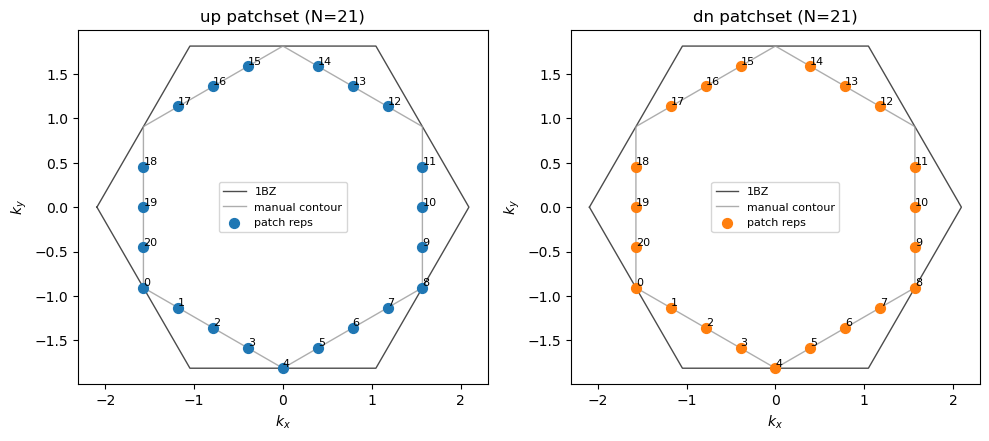

In [2]:

# ------------------------------------------------------------
# choose model / patch setup here
# ------------------------------------------------------------
MODEL_KIND = "Nagaosa"   # "Nagaosa", "StaggerFlux", "KaneMeleSOC"
MODEL_PARAMS = {"t": 1.0, "phi": 0.0}
# MODEL_PARAMS = {"t": 1.0, "l1": 0.15, "l2": 0.05}   # for KaneMeleSOC

if MODEL_KIND == "Nagaosa":
    model = KagomeNagaosa(MODEL_PARAMS, spin=True, B=None)
elif MODEL_KIND == "StaggerFlux":
    model = KagomeStaggerFlux(MODEL_PARAMS, spin=True, B=None)
elif MODEL_KIND == "KaneMeleSOC":
    model = KagomeKaneMeleSOC(MODEL_PARAMS, spin=True, B=None)
else:
    raise ValueError("Unsupported MODEL_KIND")

UP_SLICE = slice(0, 3)
DN_SLICE = slice(3, 6)
LOCAL_BAND_INDEX = 1

POINTS_PER_EDGE = 4            # 1->6, 2->12, 4->24
REMOVE_DUPLICATE_M_MODG = True
GAUGE_FIX = True
CLOSE_LOOP_GAUGE = True
GAUGE_ANCHOR = "max_component"

patchsets = {
    "up": build_exactM_patchset(
        model,
        UP_SLICE,
        LOCAL_BAND_INDEX,
        points_per_edge=POINTS_PER_EDGE,
        remove_duplicate_M_modG=REMOVE_DUPLICATE_M_MODG,
        gauge_fix=GAUGE_FIX,
        close_loop_gauge=CLOSE_LOOP_GAUGE,
        gauge_anchor=GAUGE_ANCHOR,
    ),
    "dn": build_exactM_patchset(
        model,
        DN_SLICE,
        LOCAL_BAND_INDEX,
        points_per_edge=POINTS_PER_EDGE,
        remove_duplicate_M_modG=REMOVE_DUPLICATE_M_MODG,
        gauge_fix=GAUGE_FIX,
        close_loop_gauge=CLOSE_LOOP_GAUGE,
        gauge_anchor=GAUGE_ANCHOR,
    ),
}

PATCHSETS = patchsets
NPATCH = patchsets["up"].Npatch
M6 = exact_M6_points_1bz(model)

print("Model kind:", MODEL_KIND)
print("Model params:", MODEL_PARAMS)
print("Patch counts:", {k: v.Npatch for k, v in patchsets.items()})
print("Gauge method (up/dn):", patchsets["up"].gauge_method, patchsets["dn"].gauge_method)
print("Gauge loop phase (up/dn):", patchsets["up"].gauge_loop_phase, patchsets["dn"].gauge_loop_phase)

print("\n===== exact M6 anchors in centered 1BZ =====")
for i, k in enumerate(M6):
    print(f"M{i}: k={np.round(k, 6)} | k_can={np.round(_canonicalize_k_mod_G(model, k), 6)}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
plot_patchset(patchsets["up"], ax=axes[0], title=f"up patchset (N={patchsets['up'].Npatch})", color='C0')
plot_patchset(patchsets["dn"], ax=axes[1], title=f"dn patchset (N={patchsets['dn'].Npatch})", color='C1')
plt.tight_layout()
plt.show()


# Flow

In [3]:

# ------------------------------------------------------------
# choose interaction / flow / diagnosis setup
# ------------------------------------------------------------
CASE = "U_plus_V"   # "U_only", "V_only", "U_plus_V"

if CASE == "U_only":
    U_TEST, V_TEST = 8.0, 0.0
elif CASE == "V_only":
    U_TEST, V_TEST = 0.0, 8.0
elif CASE == "U_plus_V":
    U_TEST, V_TEST = 3.0, 10.0
else:
    raise ValueError("Unsupported CASE")

T_START = 20.0
T_STOP  = 0.1
NFREQ   = 60
NSTEPS  = 200

diagnosis_Qs = [
    np.array([0.0, 0.0]),
    np.array(M6[0], dtype=float),
    np.array(M6[1], dtype=float),
    np.array(M6[-1], dtype=float),
]

# IMPORTANT:
# pp_sign must be calibrated by benchmark.
# For the current minimal-Sz0 convention, start by testing +1 and -1 explicitly.
INSTABILITY_CFG = InstabilityConfig(
    ph_sign=-1,
    pp_sign=+1,
    use_hermitian_part=True,
    project_ph_charge_q0_uniform=True,
    report_pp_singlet_q0_local_gram_both=True,
    project_pp_singlet_q0_local_gram_default=False,
    store_operator_matrices=False,
    store_all_evals=False,
)

bare_int = BareExtendedHubbard.from_kagome_model(model, U=U_TEST, V=V_TEST)
bare_sz0 = BareSZ0VertexFromInteraction(bare_int, PATCHSETS)

solver = FRGFlowSolverSZ0(
    patchsets=PATCHSETS,
    bare_vertex=bare_sz0,
    T_start=T_START,
    T_stop=T_STOP,
    n_steps=NSTEPS,
    temperature_grid="linear",
    nfreq=NFREQ,
    include_explicit_T_prefactor=True,
    max_relative_update=20,
    min_substep_fraction=1.0/512.0,
    channel_divergence_threshold=1e6,
    diagnosis_Qs=diagnosis_Qs,
    diagnosis_Landau_F=True,          # raw ph_charge kernel; instability.py handles projection
    instability_config=INSTABILITY_CFG,
    instability_stop_enabled=False,   # first stage: record only
    instability_score_threshold=None,
)

print("CASE =", CASE, " | U =", U_TEST, " V =", V_TEST)
print("T_START, T_STOP, NFREQ, NSTEPS =", T_START, T_STOP, NFREQ, NSTEPS)
print("diagnosis_Qs =", [np.round(Q, 6).tolist() for Q in diagnosis_Qs])
print("solver built.")
print("temperature path length =", len(solver.temperature_path))
print("initial channel norm =", solver.state.channel_norm())


CASE = U_plus_V  | U = 3.0  V = 10.0
T_START, T_STOP, NFREQ, NSTEPS = 20.0 0.1 60 200
diagnosis_Qs = [[0.0, 0.0], [-1.570796, -0.9069], [0.0, -1.813799], [-1.570796, 0.9069]]
solver built.
temperature path length = 200
initial channel norm = 20.000000000000007


,step_index,temperature,dT,channel_norm,rhs_norm,accepted_substeps,max_rel_update,instability,instability_reason,terminated_early,termination_reason,lead_channel,lead_spin_structure,lead_score,lead_Qx,lead_Qy,lead_projection
69,69,13.1,-0.1,9.314515e+01,1.185456e+02,1,0.145829,False,None,False,None,ph_charge,charge,1.638639,0.0,0.0,uniform_q0_charge
70,70,13.0,-0.1,1.086990e+02,1.555386e+02,1,0.166985,False,None,False,None,ph_charge,charge,1.926787,0.0,0.0,uniform_q0_charge
71,71,12.9,-0.1,1.298714e+02,2.117241e+02,1,0.194780,False,None,False,None,ph_charge,charge,2.319909,0.0,0.0,uniform_q0_charge
72,72,12.8,-0.1,1.600821e+02,3.021065e+02,1,0.232620,False,None,False,None,ph_charge,charge,2.882289,0.0,0.0,uniform_q0_charge
73,73,12.7,-0.1,2.059529e+02,4.587082e+02,1,0.286546,False,None,False,None,ph_charge,charge,3.739005,0.0,0.0,uniform_q0_charge
74,74,12.6,-0.1,2.817854e+02,7.583254e+02,1,0.368203,False,None,False,None,ph_charge,charge,5.162077,0.0,0.0,uniform_q0_charge
75,75,12.5,-0.1,4.234188e+02,1.416334e+03,1,0.502629,False,None,False,None,ph_charge,charge,7.840311,0.0,0.0,uniform_q0_charge
76,76,12.4,-0.1,7.419706e+02,3.185518e+03,1,0.752333,False,None,False,None,ph_charge,charge,13.943618,0.0,0.0,uniform_q0_charge
77,77,12.3,-0.1,1.714705e+03,9.727339e+03,1,1.311014,False,None,False,None,ph_charge,charge,33.082646,0.0,0.0,uniform_q0_charge
78,78,12.2,-0.1,6.887339e+03,5.172634e+04,1,3.016633,False,None,False,None,ph_charge,charge,140.219092,0.0,0.0,uniform_q0_charge


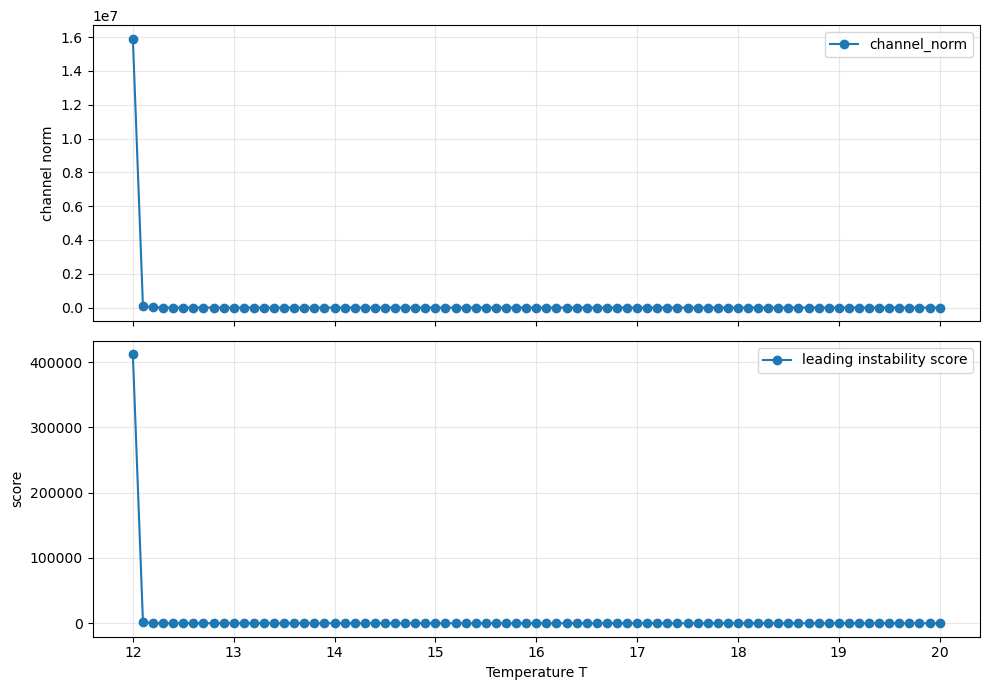

instability_record = {'step_index': 80, 'temperature': 12.0, 'dT': -0.10000000000000142, 'channel_norm': 15913885.545131778, 'rhs_norm': 158225796.08506888, 'accepted_substeps': 9, 'max_rel_update': 19.254656005251917, 'instability': True, 'instability_reason': 'channel norm=1.591e+07 exceeded channel_divergence_threshold', 'terminated_early': False, 'termination_reason': None, 'diagnosis_payload': {'representation': 'sz0_minimal', 'stored_object': 'V(p1,p2,p3; p4 via closure)', 'channel_norm': 15913885.545131778, 'diagnosis_Qs': [[0.0, 0.0], [1.5707963267948966, 0.9068996821171089], [0.0, 1.8137993642342174], [1.5707963267948966, 2.720699046351327]], 'instability_results': [{'channel_name': 'pp_singlet', 'channel_type': 'pp', 'spin_structure': 'singlet', 'Q': [0.0, 0.0], 'sign_used': 1, 'score': 55071.45904148501, 'leading_eval': 55071.45904148501, 'score_unprojected': 55071.45904148501, 'leading_eval_unprojected': 55071.45904148501, 'score_projected': 52609.43624570579, 'leading_eval

In [4]:

# ============================================================
# Debug flow run on the already-built solver
# NOTE:
#   1. this mutates solver.state
#   2. rerun the solver-construction cell before each new run
# ============================================================

history = solver.run()
history_df = pd.DataFrame(solver.history_as_dicts())

def extract_leading_from_payload(payload):
    lead = payload.get("leading_instability", None) if isinstance(payload, dict) else None
    if not isinstance(lead, dict):
        return {
            "lead_channel": None,
            "lead_spin_structure": None,
            "lead_score": np.nan,
            "lead_Qx": np.nan,
            "lead_Qy": np.nan,
            "lead_projection": None,
        }
    Q = lead.get("Q", [np.nan, np.nan])
    return {
        "lead_channel": lead.get("channel_name", None),
        "lead_spin_structure": lead.get("spin_structure", None),
        "lead_score": float(lead.get("score", np.nan)),
        "lead_Qx": float(Q[0]) if Q is not None else np.nan,
        "lead_Qy": float(Q[1]) if Q is not None else np.nan,
        "lead_projection": lead.get("projection_name", None),
    }

lead_df = pd.DataFrame([extract_leading_from_payload(p) for p in history_df["diagnosis_payload"]])
debug_df = pd.concat([history_df.drop(columns=["diagnosis_payload"]), lead_df], axis=1)

display(debug_df.tail(min(12, len(debug_df))))

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].plot(debug_df["temperature"], debug_df["channel_norm"], marker='o', label="channel_norm")
axes[0].set_ylabel("channel norm")
axes[0].invert_xaxis()
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(debug_df["temperature"], debug_df["lead_score"], marker='o', label="leading instability score")
axes[1].set_xlabel("Temperature T")
axes[1].set_ylabel("score")
axes[1].invert_xaxis()
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print("instability_record =", solver.instability_record.summary_dict() if solver.instability_record is not None else None)


# Debug

In [14]:
import numpy as np
import pandas as pd
from channels import SZ0ChannelBuilder
from instability import build_local_gram_projection_basis

# ============================================================
# 1. 选择要分析的 Q
#    默认假设 diagnosis_Qs = [Q0, QM1, QM2, QM3]
# ============================================================
Qs = [
    ("Q0",  np.array([0.0, 0.0])),
    ("QM1", np.array([1.5707963267948966, 0.9068996821171089])),
    ("QM2", np.array([0.0, 1.8137993642342174])),
    ("QM3", np.array([1.5707963267948966, 2.720699046351327])),
]

# 如果你想直接用 solver.diagnosis_Qs，也可以改成：
# Qs = [(f"Q{i}", np.array(Q, dtype=float)) for i, Q in enumerate(solver.diagnosis_Qs)]

# ============================================================
# 2. builder：只构造 raw kernel，不走 instability
#    Landau_F=True -> ph_charge 保持 raw，不做 uniform mode 投影
# ============================================================
builder = SZ0ChannelBuilder.from_solver(
    solver.current_vertex_accessor(),
    solver,
    Landau_F=True,
)

Npatch = solver.Npatch
u_const = np.ones(Npatch, dtype=complex) / np.sqrt(Npatch)

# local Gram basis for pp-singlet Q=0 analysis
gram_basis = build_local_gram_projection_basis(solver.patchsets)   # shape (Npatch, r)
P_gram = gram_basis @ gram_basis.conj().T

def hermitian_part(K):
    K = np.asarray(K, dtype=complex)
    return 0.5 * (K + K.conj().T)

def sorted_eigh(H):
    vals, vecs = np.linalg.eigh(H)
    order = np.argsort(vals)   # ascending
    return vals[order], vecs[:, order]

def rayleigh(v, H):
    v = np.asarray(v, dtype=complex)
    v = v / np.linalg.norm(v)
    return np.real(np.vdot(v, H @ v))

def overlap_with_const(v):
    v = np.asarray(v, dtype=complex)
    v = v / np.linalg.norm(v)
    return abs(np.vdot(u_const, v))

def overlap_with_gram_subspace(v):
    v = np.asarray(v, dtype=complex)
    v = v / np.linalg.norm(v)
    proj = P_gram @ v
    return float(np.linalg.norm(proj))

def summarize_pp_singlet(H):
    vals, vecs = sorted_eigh(H)

    # 最大正本征值
    pos_mask = vals > 1e-12
    if np.any(pos_mask):
        pos_idx = np.where(pos_mask)[0][-1]
        pos_eval = float(vals[pos_idx])
        pos_vec = vecs[:, pos_idx]
        pos_const_ov = overlap_with_const(pos_vec)
        pos_gram_ov = overlap_with_gram_subspace(pos_vec)
    else:
        pos_eval = None
        pos_const_ov = None
        pos_gram_ov = None

    # 最负本征值
    neg_mask = vals < -1e-12
    if np.any(neg_mask):
        neg_idx = np.where(neg_mask)[0][0]
        neg_eval = float(vals[neg_idx])
        neg_vec = vecs[:, neg_idx]
        neg_const_ov = overlap_with_const(neg_vec)
        neg_gram_ov = overlap_with_gram_subspace(neg_vec)
    else:
        neg_eval = None
        neg_const_ov = None
        neg_gram_ov = None

    return {
        "pp_pos_eval": pos_eval,
        "pp_pos_const_overlap": pos_const_ov,
        "pp_pos_gram_overlap": pos_gram_ov,
        "pp_neg_eval": neg_eval,
        "pp_neg_const_overlap": neg_const_ov,
        "pp_neg_gram_overlap": neg_gram_ov,
    }

rows = []

for tag, Q in Qs:
    kd = builder.build_kernel_dict(Q, Landau_F=True)

    K_pps = kd["pp_singlet"].matrix
    K_ppt = kd["pp_triplet"].matrix
    K_phs = kd["ph_spin"].matrix
    K_phc = kd["ph_charge"].matrix   # raw ph_charge, no projection

    H_pps = hermitian_part(K_pps)
    H_ppt = hermitian_part(K_ppt)
    H_phs = hermitian_part(K_phs)
    H_phc = hermitian_part(K_phc)

    # --- pp singlet summary ---
    pp_info = summarize_pp_singlet(H_pps)

    # --- ph spin: 最负本征值 ---
    vals_phs, vecs_phs = sorted_eigh(H_phs)
    ph_spin_most_negative = float(vals_phs[0])

    # --- ph charge raw spectrum ---
    vals_phc, vecs_phc = sorted_eigh(H_phc)
    ph_charge_max = float(vals_phc[-1])
    ph_charge_min = float(vals_phc[0])

    # --- ph charge constant mode / Landau parameter ---
    ph_charge_const_mode_eval = float(rayleigh(u_const, H_phc))

    # --- pp triplet max/min ---
    vals_ppt, _ = sorted_eigh(H_ppt)
    ppt_max = float(vals_ppt[-1])
    ppt_min = float(vals_ppt[0])

    rows.append({
        "Q_tag": tag,

        # pp singlet
        "pp_singlet_max_positive_eval": pp_info["pp_pos_eval"],
        "pp_singlet_max_positive_const_overlap": pp_info["pp_pos_const_overlap"],
        "pp_singlet_max_positive_gram_overlap": pp_info["pp_pos_gram_overlap"],

        "pp_singlet_most_negative_eval": pp_info["pp_neg_eval"],
        "pp_singlet_most_negative_const_overlap": pp_info["pp_neg_const_overlap"],
        "pp_singlet_most_negative_gram_overlap": pp_info["pp_neg_gram_overlap"],

        # pp triplet
        "pp_triplet_max_eval": ppt_max,
        "pp_triplet_min_eval": ppt_min,

        # ph spin
        "ph_spin_most_negative_eval": ph_spin_most_negative,
        "ph_spin_max_eval": float(vals_phs[-1]),

        # ph charge raw
        "ph_charge_raw_max_eval": ph_charge_max,
        "ph_charge_raw_min_eval": ph_charge_min,

        # ph charge constant mode
        "ph_charge_constant_mode_eval": ph_charge_const_mode_eval,

        # diagnostics
        "pp_singlet_herm_resid": float(np.max(np.abs(K_pps - K_pps.conj().T))),
        "ph_spin_herm_resid": float(np.max(np.abs(K_phs - K_phs.conj().T))),
        "ph_charge_herm_resid": float(np.max(np.abs(K_phc - K_phc.conj().T))),
    })

df = pd.DataFrame(rows)

print("=" * 100)
print("说明：")
print("1) pp_singlet_max_positive_eval  -> 更像 attractive pairing / s-wave SC 候选")
print("2) pp_singlet_most_negative_eval -> 更像 Cooper repulsion")
print("3) *_const_overlap / *_gram_overlap 用来判断该模是否接近 constant / local Gram 子空间")
print("4) ph_charge_constant_mode_eval  -> constant-density mode 上的 Rayleigh quotient（Landau-like parameter）")
print("5) 所有本征值都来自 Hermitian part H=(K+K^dagger)/2")
print("=" * 100)

display(df)

# ============================================================
# 3. 再额外打印更易读的逐 Q 摘要
# ============================================================
for _, r in df.iterrows():
    print("\n" + "=" * 100)
    print(f"Q = {r['Q_tag']}")
    print("-" * 100)

    print("pp_singlet:")
    print("  max positive eval      =", r["pp_singlet_max_positive_eval"], "   <-- s-wave SC candidate")
    print("  const overlap          =", r["pp_singlet_max_positive_const_overlap"])
    print("  gram-subspace overlap  =", r["pp_singlet_max_positive_gram_overlap"])
    print("  most negative eval     =", r["pp_singlet_most_negative_eval"], "   <-- Cooper repulsion")
    print("  const overlap          =", r["pp_singlet_most_negative_const_overlap"])
    print("  gram-subspace overlap  =", r["pp_singlet_most_negative_gram_overlap"])

    print("\npp_triplet:")
    print("  max eval               =", r["pp_triplet_max_eval"])
    print("  min eval               =", r["pp_triplet_min_eval"])

    print("\nph_spin:")
    print("  most negative eval     =", r["ph_spin_most_negative_eval"])
    print("  max eval               =", r["ph_spin_max_eval"])

    print("\nph_charge (raw):")
    print("  max eval               =", r["ph_charge_raw_max_eval"])
    print("  min eval               =", r["ph_charge_raw_min_eval"])
    print("  constant-mode eval     =", r["ph_charge_constant_mode_eval"], "   <-- Landau-like")

    print("\nhermitian residuals:")
    print("  pp_singlet             =", r["pp_singlet_herm_resid"])
    print("  ph_spin                =", r["ph_spin_herm_resid"])
    print("  ph_charge              =", r["ph_charge_herm_resid"])

说明：
1) pp_singlet_max_positive_eval  -> 更像 attractive pairing / s-wave SC 候选
2) pp_singlet_most_negative_eval -> 更像 Cooper repulsion
3) *_const_overlap / *_gram_overlap 用来判断该模是否接近 constant / local Gram 子空间
4) ph_charge_constant_mode_eval  -> constant-density mode 上的 Rayleigh quotient（Landau-like parameter）
5) 所有本征值都来自 Hermitian part H=(K+K^dagger)/2


,Q_tag,pp_singlet_max_positive_eval,pp_singlet_max_positive_const_overlap,pp_singlet_max_positive_gram_overlap,pp_singlet_most_negative_eval,pp_singlet_most_negative_const_overlap,pp_singlet_most_negative_gram_overlap,pp_triplet_max_eval,pp_triplet_min_eval,ph_spin_most_negative_eval,ph_spin_max_eval,ph_charge_raw_max_eval,ph_charge_raw_min_eval,ph_charge_constant_mode_eval,pp_singlet_herm_resid,ph_spin_herm_resid,ph_charge_herm_resid
0,Q0,3.182777e+07,2.179928e-01,0.462993,-1.995558e+01,0.000401,0.000710,1.957785e+01,-2.435750e+07,7.775465e+06,2.354048e+07,2.256203e+07,-2.381062e+08,2.084556e+07,43299.718564,18608.801592,708078.920124
1,QM1,1.660137e+07,2.219883e-01,0.303970,-2.058458e+07,0.303486,0.415566,4.064330e+06,-1.954360e+06,-5.764115e+06,8.081202e+06,8.081138e+06,-1.513760e+06,7.117296e+05,67800.546252,7939.747801,46862.614599
2,QM2,1.693838e+07,1.039968e-11,0.000002,-1.754996e+07,0.308611,0.422583,3.011312e+07,-6.112981e+05,-1.191579e+07,8.469003e+06,8.468524e+06,-1.819774e+07,-8.770264e+05,15669.327242,35.495517,2949.067562
3,QM3,1.660137e+07,2.219883e-01,0.303970,-2.058458e+07,0.303486,0.415566,4.064330e+06,-1.954360e+06,-5.764115e+06,8.081202e+06,8.081138e+06,-1.513760e+06,7.117296e+05,67800.546252,7939.747801,46862.614599



Q = Q0
----------------------------------------------------------------------------------------------------
pp_singlet:
  max positive eval      = 31827771.127742484    <-- s-wave SC candidate
  const overlap          = 0.2179927775975557
  gram-subspace overlap  = 0.4629929405413168
  most negative eval     = -19.95558105925048    <-- Cooper repulsion
  const overlap          = 0.00040136401488400123
  gram-subspace overlap  = 0.000710072332593333

pp_triplet:
  max eval               = 19.577845822924385
  min eval               = -24357500.25947779

ph_spin:
  most negative eval     = 7775464.924902285
  max eval               = 23540483.942533273

ph_charge (raw):
  max eval               = 22562026.660847057
  min eval               = -238106166.35818654
  constant-mode eval     = 20845561.097467646    <-- Landau-like

hermitian residuals:
  pp_singlet             = 43299.718564424664
  ph_spin                = 18608.80159231345
  ph_charge              = 708078.9201237708

Q = Q

In [8]:
import pandas as pd
import numpy as np
from channels import SZ0ChannelBuilder
from instability import diagnose_kernel_collection
from frg_kernel import FlowConfig

Qs = [
    ("Q0",  np.array([0.0, 0.0])),
    ("QM1", np.array([1.5707963267948966, 0.9068996821171089])),
    ("QM2", np.array([0.0, 1.8137993642342174])),
    ("QM3", np.array([1.5707963267948966, 2.720699046351327])),
]

builder_bare = SZ0ChannelBuilder.from_solver(
    solver_fresh.bare_vertex,
    solver_fresh,
    Landau_F=False,
)

cfg_bare = FlowConfig(
    temperature=float(solver_fresh.T_start),
    nfreq=solver_fresh.nfreq,
    include_explicit_T_prefactor=solver_fresh.include_explicit_T_prefactor,
)

rows = []
for tag, Q in Qs:
    kernel_dict = builder_bare.build_kernel_dict(Q, Landau_F=False)
    res = diagnose_kernel_collection(
        kernel_dict,
        solver_fresh.patchsets,
        solver_fresh.transfer_context(),
        cfg_bare,
        config=solver_fresh.instability_config,
    )
    for name, r in res.items():
        rows.append({
            "state": "bare",
            "Q_tag": tag,
            "channel": name,
            "score": r.score,
            "projection": r.projection_name,
            "notes": r.notes,
        })

df_bare = pd.DataFrame(rows)
display(df_bare.sort_values(["channel", "Q_tag"]))

,state,Q_tag,channel,score,projection,notes
2,bare,Q0,ph_charge,9.219016e-02,None,"(ph_bubble_mode=patchrep, ph_charge_q0_kernel_..."
6,bare,QM1,ph_charge,4.983252e-02,None,"(ph_bubble_mode=patchrep,)"
10,bare,QM2,ph_charge,4.983252e-02,None,"(ph_bubble_mode=patchrep,)"
14,bare,QM3,ph_charge,4.983252e-02,None,"(ph_bubble_mode=patchrep,)"
3,bare,Q0,ph_spin,2.491626e-02,None,"(ph_bubble_mode=patchrep,)"
7,bare,QM1,ph_spin,4.983252e-02,None,"(ph_bubble_mode=patchrep,)"
11,bare,QM2,ph_spin,4.983252e-02,None,"(ph_bubble_mode=patchrep,)"
15,bare,QM3,ph_spin,4.983252e-02,None,"(ph_bubble_mode=patchrep,)"
0,bare,Q0,pp_singlet,5.670992e-18,local_gram_q0_pp_singlet,"(pp_operator_uses_abs_bubble_weights, projecti..."
4,bare,QM1,pp_singlet,1.067732e-17,None,"(pp_operator_uses_abs_bubble_weights,)"


In [9]:
import pandas as pd
import numpy as np
from channels import SZ0ChannelBuilder
from instability import diagnose_kernel_collection
from frg_kernel import FlowConfig

def run_solver_to_step(old_solver, target_step):
    s = make_fresh_solver_from_existing(old_solver)
    temps = s.temperature_path
    # step 0 是 bare/init
    if target_step == 0:
        return s
    for i in range(min(target_step, len(temps)-1)):
        T_old = float(temps[i])
        T_new = float(temps[i+1])
        rec = s.step(T_old, T_new - T_old)
        s.history.append(rec)
        if rec.terminated_early or rec.channel_norm >= s.channel_divergence_threshold:
            break
    return s

check_steps = [0, 3, 6, 10, 15]   # 你也可以加 20
rows = []

for st in check_steps:
    s = run_solver_to_step(solver, st)

    builder = SZ0ChannelBuilder.from_solver(
        s.current_vertex_accessor(),
        s,
        Landau_F=False,
    )
    cfg = FlowConfig(
        temperature=float(s.state.T),
        nfreq=s.nfreq,
        include_explicit_T_prefactor=s.include_explicit_T_prefactor,
    )

    for tag, Q in Qs:
        kernel_dict = builder.build_kernel_dict(Q, Landau_F=False)
        res = diagnose_kernel_collection(
            kernel_dict,
            s.patchsets,
            s.transfer_context(),
            cfg,
            config=s.instability_config,
        )
        for name, r in res.items():
            rows.append({
                "step": st,
                "T": s.state.T,
                "Q_tag": tag,
                "channel": name,
                "score": r.score,
                "projection": r.projection_name,
            })

df_early = pd.DataFrame(rows)
display(df_early.sort_values(["step", "channel", "Q_tag"]))

,step,T,Q_tag,channel,score,projection
2,0,20.0,Q0,ph_charge,0.092190,None
6,0,20.0,QM1,ph_charge,0.049833,None
10,0,20.0,QM2,ph_charge,0.049833,None
14,0,20.0,QM3,ph_charge,0.049833,None
3,0,20.0,Q0,ph_spin,0.024916,None
...,...,...,...,...,...,...
76,15,18.5,QM3,pp_singlet,0.010241,None
65,15,18.5,Q0,pp_triplet,0.051473,None
69,15,18.5,QM1,pp_triplet,0.050166,None
73,15,18.5,QM2,pp_triplet,0.037438,None


In [10]:
import pandas as pd
import numpy as np

def summarize_q0_vs_qm(df):
    rows = []
    for st in sorted(df["step"].unique()):
        sub = df[df["step"] == st]

        q0 = sub[sub["Q_tag"] == "Q0"]
        qm = sub[sub["Q_tag"] != "Q0"]

        q0_best = q0.loc[q0["score"].idxmax()]
        qm_best = qm.loc[qm["score"].idxmax()]

        rows.append({
            "step": st,
            "T": float(sub["T"].iloc[0]),
            "q0_best_channel": q0_best["channel"],
            "q0_best_score": q0_best["score"],
            "qm_best_channel": qm_best["channel"],
            "qm_best_Q": qm_best["Q_tag"],
            "qm_best_score": qm_best["score"],
            "q0_minus_qm": q0_best["score"] - qm_best["score"],
        })
    return pd.DataFrame(rows)

df_qcmp = summarize_q0_vs_qm(df_early)
display(df_qcmp)

,step,T,q0_best_channel,q0_best_score,qm_best_channel,qm_best_Q,qm_best_score,q0_minus_qm
0,0,20.0,ph_charge,0.092190,pp_triplet,QM3,0.049833,0.042358
1,3,19.7,ph_charge,0.096959,ph_charge,QM2,0.050068,0.046891
2,6,19.4,ph_charge,0.102306,ph_charge,QM2,0.050411,0.051895
3,10,19.0,ph_charge,0.110429,ph_spin,QM3,0.051026,0.059403
4,15,18.5,ph_charge,0.122444,ph_charge,QM3,0.053086,0.069358


In [11]:
import numpy as np
import pandas as pd
from channels import SZ0ChannelBuilder

def top_eval(K):
    H = 0.5 * (K + K.conj().T)
    return np.linalg.eigvalsh(H)[-1]

def collect_vd_vx_summary(builder, state_name):
    rows = []
    for tag, Q in Qs:
        Vd = builder.ph_direct(Q).matrix
        Vx = builder.ph_exchange(Q).matrix
        C  = builder.ph_charge(Q, Landau_F=True).matrix
        S  = builder.ph_spin(Q).matrix
        rows.append({
            "state": state_name,
            "Q_tag": tag,
            "top_Vd": top_eval(Vd),
            "top_Vx": top_eval(Vx),
            "top_Vd_minus_2Vx": top_eval(C),
            "top_ph_spin": top_eval(S),
            "maxabs_Vd": np.max(np.abs(Vd)),
            "maxabs_Vx": np.max(np.abs(Vx)),
            "maxabs_Vd_minus_2Vx": np.max(np.abs(C)),
        })
    return rows

builder_bare = SZ0ChannelBuilder.from_solver(solver_fresh.bare_vertex, solver_fresh, Landau_F=True)
builder_final = SZ0ChannelBuilder.from_solver(solver.current_vertex_accessor(), solver, Landau_F=True)

rows = []
rows += collect_vd_vx_summary(builder_bare, "bare")
rows += collect_vd_vx_summary(builder_final, "final")
df_vdx = pd.DataFrame(rows)
display(df_vdx)

,state,Q_tag,top_Vd,top_Vx,top_Vd_minus_2Vx,top_ph_spin,maxabs_Vd,maxabs_Vx,maxabs_Vd_minus_2Vx
0,bare,Q0,8.539735e-15,6.800000e+01,5.810000e+02,8.539735e-15,1.150000e+01,2.000000e+01,4.000000e+01
1,bare,QM1,3.496581e-15,3.400000e+01,9.065208e-15,3.496581e-15,2.000000e+01,8.500000e+00,2.850000e+01
2,bare,QM2,1.200879e-14,3.400000e+01,2.107023e-14,1.200879e-14,2.000000e+01,8.500000e+00,2.850000e+01
3,bare,QM3,6.568403e-15,3.400000e+01,1.124950e-14,6.568403e-15,2.000000e+01,8.500000e+00,2.850000e+01
4,final,Q0,2.354048e+07,1.247814e+08,2.256203e+07,2.354048e+07,1.591389e+07,1.591389e+07,2.697233e+07
5,final,QM1,8.081202e+06,5.609640e+05,8.081138e+06,8.081202e+06,8.067815e+06,4.106499e+06,8.067752e+06
6,final,QM2,8.469003e+06,3.141418e+06,8.468524e+06,8.469003e+06,1.191577e+07,3.140789e+06,1.819735e+07
7,final,QM3,8.081202e+06,5.609640e+05,8.081138e+06,8.081202e+06,8.067815e+06,4.106499e+06,8.067752e+06


In [12]:
import pandas as pd
import numpy as np

track_steps = [0, 1, 2, 3, 4, 5, 6, 8, 10]

rows = []
for st in track_steps:
    s = run_solver_to_step(solver, st)

    builder = SZ0ChannelBuilder.from_solver(
        s.current_vertex_accessor(),
        s,
        Landau_F=False,
    )
    cfg = FlowConfig(
        temperature=float(s.state.T),
        nfreq=s.nfreq,
        include_explicit_T_prefactor=s.include_explicit_T_prefactor,
    )

    # 只记录四个你最关心的量
    channels_to_track = {
        ("ph_charge", "Q0"): None,
        ("ph_spin", "Q0"): None,
        ("ph_charge", "QM_best"): None,
        ("ph_spin", "QM_best"): None,
    }

    ph_charge_qm = []
    ph_spin_qm = []

    for tag, Q in Qs:
        res = diagnose_kernel_collection(
            builder.build_kernel_dict(Q, Landau_F=False),
            s.patchsets,
            s.transfer_context(),
            cfg,
            config=s.instability_config,
        )

        if tag == "Q0":
            channels_to_track[("ph_charge", "Q0")] = res["ph_charge"].score
            channels_to_track[("ph_spin", "Q0")] = res["ph_spin"].score
        else:
            ph_charge_qm.append(res["ph_charge"].score)
            ph_spin_qm.append(res["ph_spin"].score)

    channels_to_track[("ph_charge", "QM_best")] = max(ph_charge_qm)
    channels_to_track[("ph_spin", "QM_best")] = max(ph_spin_qm)

    rows.append({
        "step": st,
        "T": s.state.T,
        "ph_charge_q0": channels_to_track[("ph_charge", "Q0")],
        "ph_spin_q0": channels_to_track[("ph_spin", "Q0")],
        "ph_charge_qm_best": channels_to_track[("ph_charge", "QM_best")],
        "ph_spin_qm_best": channels_to_track[("ph_spin", "QM_best")],
    })

df_track = pd.DataFrame(rows)
display(df_track)

,step,T,ph_charge_q0,ph_spin_q0,ph_charge_qm_best,ph_spin_qm_best
0,0,20.0,0.092190,0.024916,0.049833,0.049833
1,1,19.9,0.093718,0.024956,0.049897,0.049887
2,2,19.8,0.095307,0.025014,0.049976,0.049957
3,3,19.7,0.096959,0.025088,0.050068,0.050043
4,4,19.6,0.098674,0.025179,0.050171,0.050143
5,5,19.5,0.100456,0.025284,0.050286,0.050256
6,6,19.4,0.102306,0.025403,0.050411,0.050382
7,8,19.2,0.106217,0.025682,0.050687,0.050676
8,10,19.0,0.110429,0.026011,0.050994,0.051026


In [13]:
def debug_rhs_Q(solver, Q):
    rhs = solver.compute_vertex_rhs(solver.state.T)

    # 你需要写一个函数，把 rhs 投影到某个 Q channel
    # 或者直接比较对应 (p1,p2,p3) block

    return rhs